In [7]:
import warnings
warnings.filterwarnings(action='once')
from panel_segmentation import utils
import glob
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import shift
from kornia.geometry import ImageRegistrator
from scipy import signal
from mmengine import Config
from mmdet.apis import init_detector, inference_detector
import mmcv
from mmdet.registry import VISUALIZERS
import numpy as np
import os
import cv2
import torch
import torch.nn.functional as F
import kornia

In [8]:
# Additional functions for running process
def mask_to_np(img, masks, labels):
    """
    Convert a mask to numpy array 
    """
    mask_array = np.zeros((img.shape[0], img.shape[1]))
    for idx in range(len(masks)):
        ann = masks[idx]
        label = int(labels[idx]) +1
        mask_array = np.maximum(mask_array, ann.detach().numpy().astype(int) * label)
    return mask_array

# Hurricane Damage Detection

Download the pre- and post-hurricane models from the Hugging Face repository, if they're not already present in the /models folder (https://huggingface.co/kperrynrel/panel-segmentation-models/tree/main).

In [9]:
# Pre-hurricane model
utils.downloadModel(
    filename="pre_hurricane_model.pth"
)

# Post-hurricane model
utils.downloadModel(
    filename="post_hurricane_model.pth"
)

Model already exists at C:\Users\kperry\OneDrive - NLR\Documents\source\repos\Panel-Segmentation\panel_segmentation\models\pre_hurricane_model.pth, skipping download.
Model already exists at C:\Users\kperry\OneDrive - NLR\Documents\source\repos\Panel-Segmentation\panel_segmentation\models\post_hurricane_model.pth, skipping download.


'C:\\Users\\kperry\\OneDrive - NLR\\Documents\\source\\repos\\Panel-Segmentation\\panel_segmentation\\models\\post_hurricane_model.pth'

The following example uses the hurricane damage detection pipeline to detect hurricane damage on solar installations given a satellite imagery. First, let's pull some example images down from the hurricane data examples folder. This data is taken from the NOAA scan post-Hurricane Maria.

In [10]:
example_pre_hurricane_images = glob.glob(
    "../../../panel_segmentation/examples/puerto_rico_pre_hurricane_images/*.png")

Let's load in the pre- and post-hurricane models to run inference on.

In [11]:
# Read in pre-storm model
cfg = Config.fromfile("../../../panel_segmentation/models/pre_hurricane_config.py")
checkpoint_file = "../../../panel_segmentation/models/pre_hurricane_model.pth"
pre_model = init_detector(cfg, device='cpu')
checkpoint = torch.load(checkpoint_file, map_location='cpu', weights_only=False)
pre_model.load_state_dict(checkpoint['state_dict'])

# Read in post-storm model
cfg = Config.fromfile("../../../panel_segmentation/models/post_hurricane_config.py")
checkpoint_file = "../../../panel_segmentation/models/post_hurricane_model.pth"
post_model = init_detector(cfg, device='cpu')
checkpoint = torch.load(checkpoint_file, map_location='cpu', weights_only=False)
post_model.load_state_dict(checkpoint['state_dict'])
# Build visualizer for post-storm model
visualizer = VISUALIZERS.build(post_model.cfg.visualizer)

C:\Users\kperry\.conda\envs\deep-learning\Lib\site-packages\mmdet\apis\inference.py:70: UserWarning: checkpoint is None, use COCO classes by default.
  warnings.warn('checkpoint is None, use COCO classes by default.')
C:\Users\kperry\.conda\envs\deep-learning\Lib\site-packages\mmdet\apis\inference.py:70: UserWarning: checkpoint is None, use COCO classes by default.
  warnings.warn('checkpoint is None, use COCO classes by default.')
C:\Users\kperry\.conda\envs\deep-learning\Lib\site-packages\mmengine\utils\manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


Run the example images through both models, and calculate the level hurricane damage.

C:\Users\kperry\.conda\envs\deep-learning\Lib\site-packages\mmdet\models\layers\se_layer.py:158: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
C:\Users\kperry\.conda\envs\deep-learning\Lib\site-packages\mmdet\models\backbones\csp_darknet.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
C:\Users\kperry\.conda\envs\deep-learning\Lib\site-packages\numpy\_core\fromnumeric.py:45: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return conv.wrap(result, to_scalar=False)


../../../panel_segmentation/examples/puerto_rico_pre_hurricane_images\20170922aC0645700w182100n_18.33663412854537_-64.94846397928669.png


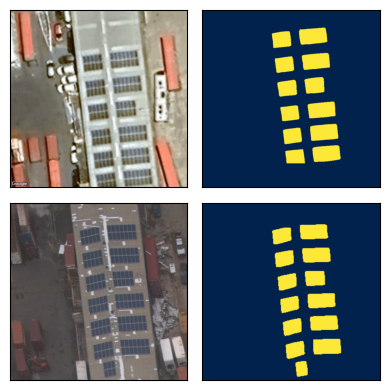

../../../panel_segmentation/examples/puerto_rico_pre_hurricane_images\20170923aC0643730w174630n_17.755921683652495_-64.61565564054749.png


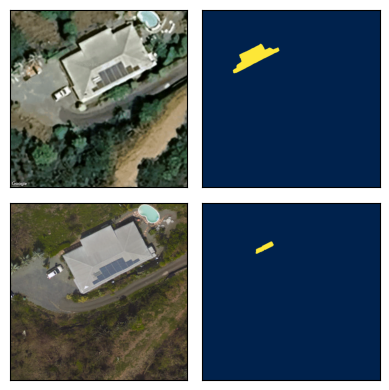

../../../panel_segmentation/examples/puerto_rico_pre_hurricane_images\20170923bC0644630w174630n_17.753614194913194_-64.76843834010256.png


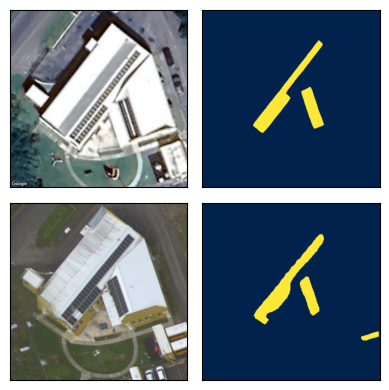

../../../panel_segmentation/examples/puerto_rico_pre_hurricane_images\20170923bC0644630w174630n_17.77098719486288_-64.76338464575298.png


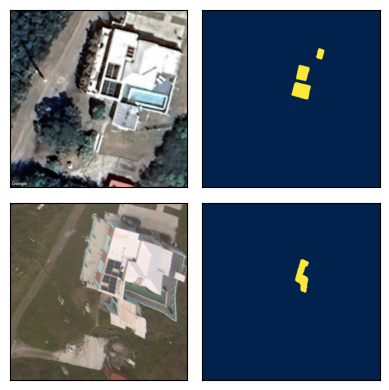

../../../panel_segmentation/examples/puerto_rico_pre_hurricane_images\20170923bC0644800w174630n_17.752847839809693_-64.77722415663133.png


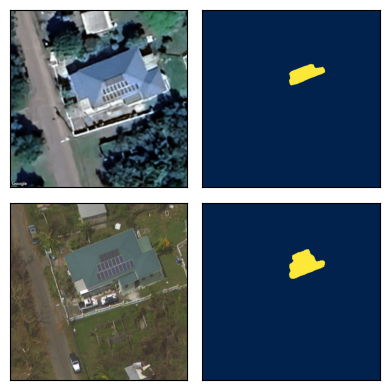

../../../panel_segmentation/examples/puerto_rico_pre_hurricane_images\20170924aC0654800w180900n_18.130325377062075_-65.78995277940152.png


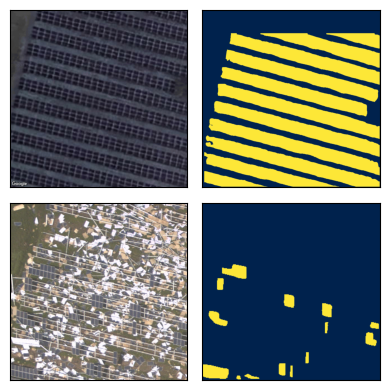

In [12]:
for image in example_pre_hurricane_images:
    pre_img = mmcv.imread(image, channel_order='rgb')
    pre_result = inference_detector(pre_model, pre_img)
    pre_predictions = pre_result._pred_instances
    pre_masks, pre_labels, pre_scores = pre_predictions.masks, pre_predictions.labels, pre_predictions.scores
    # Cutoff any of the scores under threshold
    idx_to_keep = np.argwhere(pre_scores>=0.5).tolist()[0]
    pre_masks, pre_labels = pre_masks[idx_to_keep], pre_labels[idx_to_keep]
    # Run inference on the corresponding post-storm image
    destruction_img = os.path.join(
        "../../../panel_segmentation/examples/puerto_rico_post_hurricane_images",
        os.path.basename(image))
    post_img = mmcv.imread(destruction_img, channel_order='rgb')
    post_result = inference_detector(post_model,  post_img)
    post_predictions = post_result._pred_instances
    post_masks, post_labels, post_scores= post_predictions.masks, post_predictions.labels, post_predictions.scores
    idx_to_keep = np.argwhere(post_scores>=0.5).tolist()[0]
    post_masks, post_labels = post_masks[idx_to_keep], post_labels[idx_to_keep]
    # Convert mask to image
    # Pre-storm mask
    pre_anns_img = mask_to_np(pre_img, pre_masks, pre_labels)
    post_anns_img = mask_to_np(post_img, post_masks, post_labels)
    # Post-correction in case pre- and post- images are not the same size
    post_anns_img = cv2.resize(post_anns_img, dsize=(pre_img.shape[0], pre_img.shape[1]), 
                                interpolation=cv2.INTER_CUBIC)
    # Perform 2-D cross-correlation on the pre-storm mask to align it with the
    # post-storm mask (via FFT)
    cross_corr = signal.correlate(post_anns_img, pre_anns_img, mode='same', method='fft')
    # Shift the image based on highest cross-correlation value
    new_center = np.unravel_index(cross_corr.argmax(), cross_corr.shape)
    translation_x, translation_y = new_center[1]-pre_anns_img.shape[0]/2, new_center[0]-pre_anns_img.shape[1]/2
    pre_anns_img = shift(pre_anns_img, [translation_y, translation_x], cval=0)
    pre_anns_img = np.round(pre_anns_img[:pre_anns_img.shape[0], :pre_anns_img.shape[1]])
    # Convert to tensor to run Image Registration
    pre_anns_tensor = torch.from_numpy(np.array(
        pre_anns_img.reshape(1,1,pre_anns_img.shape[0],
                             pre_anns_img.shape[1])).astype(np.float32))
    post_anns_tensor = torch.from_numpy(np.array(
        post_anns_img.reshape(1,1,post_anns_img.shape[0],
                              post_anns_img.shape[1])).astype(np.float32))
    # Registration against the two masks
    registrator = ImageRegistrator('similarity',
                                    tolerance=.001, loss_fn=F.mse_loss)
    model = registrator.register(pre_anns_tensor, post_anns_tensor)
    aligned_mask = registrator.warp_src_into_dst(pre_anns_tensor)
    # Align the image as well
    aligned_no_damage_img = registrator.warp_src_into_dst(pre_anns_tensor)
    # Plot results
    print(image)
    fig, axs = plt.subplots(2, 2, figsize=(4,4))
    axs = axs.flatten()
    axs[0].imshow(pre_img)
    axs[1].imshow(
            np.round(kornia.tensor_to_image(aligned_mask[0].sum(dim=0, keepdim=True))),
            cmap=plt.get_cmap('cividis'),
        )
    axs[2].imshow(post_img)
    axs[3].imshow(
            np.round(kornia.tensor_to_image(post_anns_tensor[0].sum(dim=0, keepdim=True))),
            cmap=plt.get_cmap('cividis'),
        )
    plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[]);
    fig.tight_layout()
    plt.show()
    plt.close()        